In [1]:
import numpy as np
import pandas as pd

In [2]:
weather_df = pd.read_csv('./data/weather_2016_2025.csv', encoding = 'cp949')
weather_df.head()

,지점,지점명,일시,평균기온(°C),최저기온(°C),최고기온(°C),강수 계속시간(hr),일강수량(mm),최대 풍속(m/s),평균 풍속(m/s),...,일 최심적설(cm),평균 전운량(1/10),평균 중하층운량(1/10),평균 지면온도(°C),평균 5cm 지중온도(°C),평균 10cm 지중온도(°C),평균 20cm 지중온도(°C),평균 30cm 지중온도(°C),합계 대형증발량(mm),합계 소형증발량(mm)
0,90,속초,2016-01-01,3.6,-2.3,7.6,NaN,NaN,6.3,2.3,...,NaN,NaN,NaN,1.4,NaN,NaN,NaN,NaN,NaN,NaN
1,90,속초,2016-01-02,8.4,5.0,11.5,NaN,NaN,8.0,3.1,...,NaN,NaN,NaN,5.4,NaN,NaN,NaN,NaN,NaN,NaN
2,90,속초,2016-01-03,6.7,2.4,9.8,NaN,NaN,5.3,1.9,...,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
3,90,속초,2016-01-04,5.4,0.8,9.0,NaN,NaN,5.9,2.7,...,NaN,NaN,NaN,4.2,NaN,NaN,NaN,NaN,NaN,NaN
4,90,속초,2016-01-05,0.6,-2.6,4.4,NaN,NaN,6.1,2.5,...,NaN,NaN,NaN,1.3,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 348870 entries, 0 to 348869
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   지점                348870 non-null  int64  
 1   지점명               348870 non-null  str    
 2   일시                348870 non-null  str    
 3   평균기온(°C)          348373 non-null  float64
 4   최저기온(°C)          348716 non-null  float64
 5   최고기온(°C)          348722 non-null  float64
 6   강수 계속시간(hr)       33584 non-null   float64
 7   일강수량(mm)          132066 non-null  float64
 8   최대 풍속(m/s)        348424 non-null  float64
 9   평균 풍속(m/s)        348338 non-null  float64
 10  최다풍향(16방위)        347878 non-null  float64
 11  평균 이슬점온도(°C)      348089 non-null  float64
 12  최소 상대습도(%)        348587 non-null  float64
 13  평균 상대습도(%)        348121 non-null  float64
 14  평균 증기압(hPa)       348083 non-null  float64
 15  평균 현지기압(hPa)      348352 non-null  float64
 16  최고 해면기압(hPa)      348626 non-nu

In [4]:
weather_df.isnull().sum()


지점                       0
지점명                      0
일시                       0
평균기온(°C)               497
최저기온(°C)               154
최고기온(°C)               148
강수 계속시간(hr)         315286
일강수량(mm)            216804
최대 풍속(m/s)             446
평균 풍속(m/s)             532
최다풍향(16방위)             992
평균 이슬점온도(°C)           781
최소 상대습도(%)             283
평균 상대습도(%)             749
평균 증기압(hPa)            787
평균 현지기압(hPa)           518
최고 해면기압(hPa)           244
최저 해면기압(hPa)           297
평균 해면기압(hPa)           579
합계 일사량(MJ/m2)       173963
일 최심적설(cm)          345407
평균 전운량(1/10)         71291
평균 중하층운량(1/10)       77115
평균 지면온도(°C)            521
평균 5cm 지중온도(°C)     247102
평균 10cm 지중온도(°C)    247021
평균 20cm 지중온도(°C)    246998
평균 30cm 지중온도(°C)    246970
합계 대형증발량(mm)        181003
합계 소형증발량(mm)        179443
dtype: int64

### 기상 데이터 컬럼 제거 및 결측치 처리

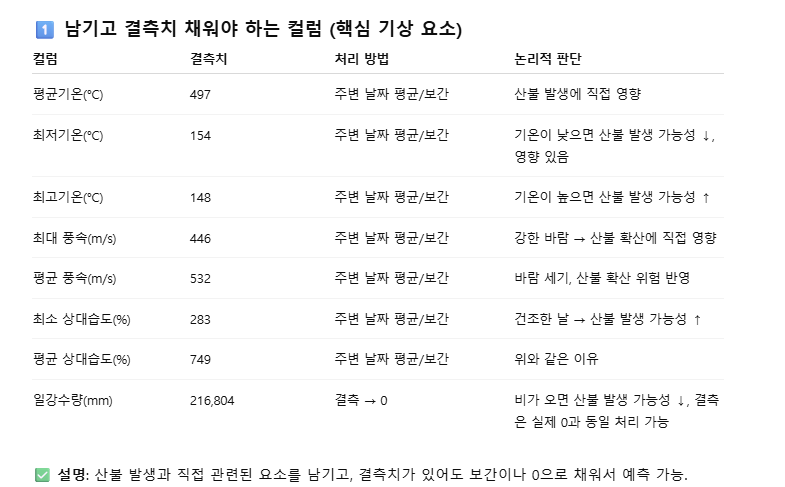

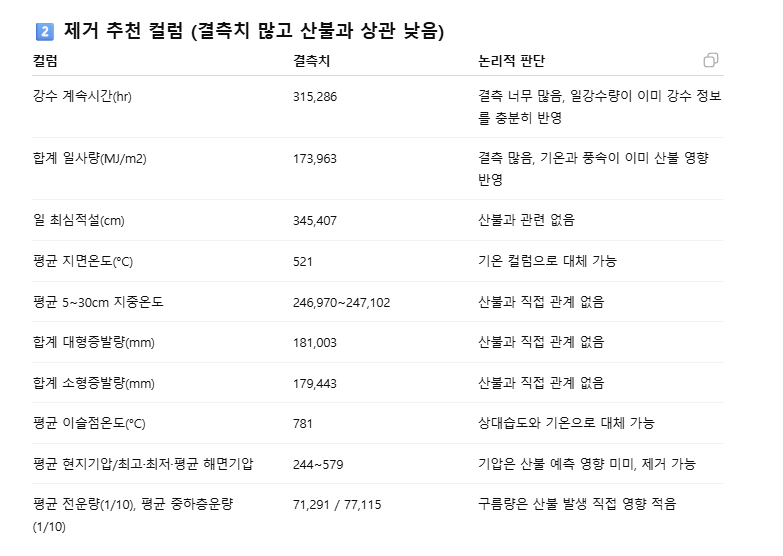

In [5]:
# 컬럼 제거
drop_cols = [
    '강수 계속시간(hr)',
    '합계 일사량(MJ/m2)',
    '일 최심적설(cm)',
    '평균 지면온도(°C)',
    '평균 5cm 지중온도(°C)',
    '평균 10cm 지중온도(°C)',
    '평균 20cm 지중온도(°C)',
    '평균 30cm 지중온도(°C)',
    '합계 대형증발량(mm)',
    '합계 소형증발량(mm)',
    '평균 이슬점온도(°C)',
    '평균 전운량(1/10)',
    '평균 중하층운량(1/10)',
    '평균 증기압(hPa)',
    '평균 현지기압(hPa)',
    '최고 해면기압(hPa)',
    '최저 해면기압(hPa)',
    '평균 해면기압(hPa)',
    '최다풍향(16방위)'
]

# 컬럼 제거
weather_df.drop(columns=drop_cols, inplace=True)

In [6]:
# 날짜 컬럼을 datetime으로 변환
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

# 연, 월, 일 컬럼 생성 (월/일 기준으로 그룹바이)
weather_df['월'] = weather_df['일시'].dt.month
weather_df['일'] = weather_df['일시'].dt.day

weather_df.head()

,지점,지점명,일시,평균기온(°C),최저기온(°C),최고기온(°C),일강수량(mm),최대 풍속(m/s),평균 풍속(m/s),최소 상대습도(%),평균 상대습도(%),월,일
0,90,속초,2016-01-01,3.6,-2.3,7.6,NaN,6.3,2.3,30.0,44.9,1,1
1,90,속초,2016-01-02,8.4,5.0,11.5,NaN,8.0,3.1,38.0,50.4,1,2
2,90,속초,2016-01-03,6.7,2.4,9.8,NaN,5.3,1.9,53.0,80.0,1,3
3,90,속초,2016-01-04,5.4,0.8,9.0,NaN,5.9,2.7,13.0,32.6,1,4
4,90,속초,2016-01-05,0.6,-2.6,4.4,NaN,6.1,2.5,9.0,16.8,1,5


In [7]:
# 일강수량 -> 결측치 0으로 채움
weather_df['일강수량(mm)'] = weather_df['일강수량(mm)'].fillna(0)

# 습도 -> 지역별 선형보간(습도 결측치 전후일 두날의 평균으로 채움)
weather_df.sort_values(['지점', '일시'], inplace=True)
weather_df['평균 상대습도(%)'] = weather_df.groupby('지점')['평균 상대습도(%)'].transform(lambda x: x.interpolate(method='linear'))
weather_df['최소 상대습도(%)'] = weather_df.groupby('지점')['최소 상대습도(%)'].transform(lambda x: x.interpolate(method='linear'))

# 월/일 컬럼 생성 (이미 만들어졌는지 확인)
weather_df['월'] = weather_df['일시'].dt.month
weather_df['일'] = weather_df['일시'].dt.day

# 나머지 주요 기온/풍속: 지역별 + 월/일 그룹 평균으로 결측치 채우기
cols_group_fill = ['평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '최대 풍속(m/s)', '평균 풍속(m/s)']

for col in cols_group_fill:
    weather_df[col] = weather_df.groupby(['지점', '월', '일'])[col].transform(lambda x: x.fillna(x.mean()))

# 처리 완료 확인
weather_df.isnull().sum()


지점            0
지점명           0
일시            0
평균기온(°C)      0
최저기온(°C)      0
최고기온(°C)      0
일강수량(mm)      0
최대 풍속(m/s)    0
평균 풍속(m/s)    0
최소 상대습도(%)    0
평균 상대습도(%)    1
월             0
일             0
dtype: int64

- 평균 상대습도 결측치 하나 남음 -> 양쪽에 NaN이 없을 때만 선형 보간이 가능한데 이 경우가 아니라서

In [8]:
# 나음 결측치 1개 처리
weather_df['평균 상대습도(%)'] = weather_df['평균 상대습도(%)'].fillna(method='ffill').fillna(method='bfill')


TypeError: NDFrame.fillna() got an unexpected keyword argument 'method'

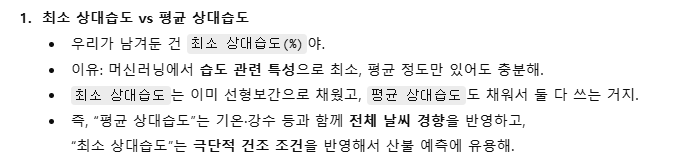

In [ ]:
# 결측치 처리 확인
weather_df.isnull().sum()

지점            0
지점명           0
일시            0
평균기온(°C)      0
최저기온(°C)      0
최고기온(°C)      0
일강수량(mm)      0
최대 풍속(m/s)    0
평균 풍속(m/s)    0
최소 상대습도(%)    0
평균 상대습도(%)    0
월             0
일             0
dtype: int64

In [ ]:
weather_df.head()

,지점,지점명,일시,평균기온(°C),최저기온(°C),최고기온(°C),일강수량(mm),최대 풍속(m/s),평균 풍속(m/s),최소 상대습도(%),평균 상대습도(%),월,일
0,90,속초,2016-01-01,3.6,-2.3,7.6,0.0,6.3,2.3,30.0,44.9,1,1
1,90,속초,2016-01-02,8.4,5.0,11.5,0.0,8.0,3.1,38.0,50.4,1,2
2,90,속초,2016-01-03,6.7,2.4,9.8,0.0,5.3,1.9,53.0,80.0,1,3
3,90,속초,2016-01-04,5.4,0.8,9.0,0.0,5.9,2.7,13.0,32.6,1,4
4,90,속초,2016-01-05,0.6,-2.6,4.4,0.0,6.1,2.5,9.0,16.8,1,5


##### 2015 앞에거 5일치 추가하기

In [ ]:
fivedays_df = pd.read_csv('./data/weather_20151227_20151231.csv', encoding='cp949')

fivedays_df['일시'] = pd.to_datetime(fivedays_df['일시'])

# weather_df의 컬럼들 중 fivedays에도 존재하는 컬럼명만 리스트로 만들기
common_cols = [col for col in weather_df.columns if col in fivedays_df]

# 공통된 컬럼만 추출
fivedays_df = fivedays_df[common_cols]

full_df = pd.concat([fivedays_df, weather_df], axis=0)

# 날짜순, 지점별로 다시 정렬 (이걸 해야 shift가 정확히 작동합니다)
full_df = full_df.sort_values(['지점명', '일시']).reset_index(drop=True)




##### '실효습도' column 생성

In [ ]:
# '실효습도' column 생성
r = 0.7
weighted_sum = 0

for i in range(6): # 0부터 5까지
    h_i = full_df.groupby('지점명')['평균 상대습도(%)'].shift(i)
    weighted_sum += (r**i) * h_i

full_df['실효습도'] = (1-r) * weighted_sum

# '일시' 컬럼의 연도가 2016년 이상인 것만 남기기
weather_df = full_df[full_df['일시'].dt.year >= 2016].copy()

In [ ]:
# 실효습도 null값이 2016(데이터의 시작)이 아닌 지점 확인
print(weather_df[weather_df['실효습도'].isnull() & (weather_df['일시'].dt.year != 2016)].shape)
display(weather_df[weather_df['실효습도'].isnull() & (weather_df['일시'].dt.year != 2016)])
# -> 서청주 2023, 세종 2019, 북부산 2023 확인 5개씩 15개 확인

# 실효습도가 NaN인 행(신설 지점 초반 데이터)만 삭제
weather_df = weather_df.dropna(subset=['실효습도'])

weather_df.isna().sum()

(18, 15)


,지점,지점명,일시,평균기온(°C),최저기온(°C),최고기온(°C),일강수량(mm),최대 풍속(m/s),평균 풍속(m/s),최소 상대습도(%),평균 상대습도(%),일 최심적설(cm),월,일,실효습도
132578,93,북춘천,2019-09-11,3.7,1.2,7.2,1.5,3.6,1.2,70.0,89.3,0.0,1.0,14.0,NaN
132579,93,북춘천,2019-09-12,0.0,-1.2,1.6,8.9,2.6,0.5,90.0,97.0,5.0,1.0,15.0,NaN
132580,93,북춘천,2019-09-13,-4.6,-9.6,-1.2,0.0,2.9,1.3,63.0,82.1,3.6,1.0,16.0,NaN
132581,93,북춘천,2019-09-14,-6.0,-9.9,-3.5,0.1,1.6,0.6,63.0,85.6,3.4,1.0,17.0,NaN
132582,93,북춘천,2019-09-15,-5.1,-9.9,0.6,0.0,2.8,0.6,44.0,84.4,4.0,1.0,18.0,NaN
154215,181,서청주,2022-08-30,14.1,12.0,20.3,32.5,7.5,3.9,82.0,90.4,0.0,5.0,6.0,NaN
154216,181,서청주,2022-08-31,12.1,7.4,15.0,0.2,6.4,2.5,57.0,75.8,0.0,5.0,7.0,NaN
154217,181,서청주,2022-09-01,13.0,4.5,22.4,0.0,5.3,1.5,25.0,64.8,0.0,5.0,8.0,NaN
154218,181,서청주,2022-09-02,15.5,5.8,24.9,0.0,4.8,1.5,21.0,63.1,0.0,5.0,9.0,NaN
154219,181,서청주,2022-09-03,17.3,8.5,25.7,0.0,4.3,1.6,24.0,55.8,0.0,5.0,10.0,NaN


지점            0
지점명           0
일시            0
평균기온(°C)      0
최저기온(°C)      0
최고기온(°C)      0
일강수량(mm)      0
최대 풍속(m/s)    0
평균 풍속(m/s)    0
최소 상대습도(%)    0
평균 상대습도(%)    0
일 최심적설(cm)    0
월             0
일             0
실효습도          0
dtype: int64

##### 전처리 오래 걸리므로 파일 저장

In [ ]:
# 한글 데이터가 포함되어 있으므로 encoding='utf-8-sig'를 권장합니다 (엑셀에서도 잘 열림)
# index=False를 안 하면 나중에 불러올 때 'Unnamed: 0' 컬럼이 생기니 꼭 넣어주세요.
weather_df.to_csv('./data/weather_preprocessed.csv', index=False, encoding='utf-8-sig')

print("전처리 완료 데이터 저장 성공!")
# 저장했던 파일 불러오기
weather_df = pd.read_csv('./data/weather_preprocessed.csv', encoding='utf-8-sig')

# 불러온 후 '일시' 컬럼이 다시 object(str)로 변했을 수 있으니 datetime으로 다시 바꿔주면 완벽합니다.
weather_df['일시'] = pd.to_datetime(weather_df['일시'])

weather_df.isna().sum()
weather_df

전처리 완료 데이터 저장 성공!


,지점,지점명,일시,평균기온(°C),최저기온(°C),최고기온(°C),일강수량(mm),최대 풍속(m/s),평균 풍속(m/s),최소 상대습도(%),평균 상대습도(%),일 최심적설(cm),월,일,실효습도
0,105,강릉,2016-01-01,5.1,2.1,8.9,0.0,9.6,4.8,20.0,33.0,0.0,1.0,1.0,32.568148
1,105,강릉,2016-01-02,9.1,5.5,11.2,0.0,9.5,4.9,35.0,43.8,0.0,1.0,2.0,34.257676
2,105,강릉,2016-01-03,9.0,5.3,13.8,0.0,5.7,2.6,31.0,55.8,0.0,1.0,3.0,40.240365
3,105,강릉,2016-01-04,7.4,3.3,12.0,0.0,6.9,3.4,13.0,33.8,0.0,1.0,4.0,37.708246
4,105,강릉,2016-01-05,3.0,0.4,7.7,0.0,5.7,3.7,10.0,16.3,0.0,1.0,5.0,29.817512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348813,169,흑산도,2025-11-05,10.0,6.3,14.5,0.0,9.7,5.6,56.0,71.8,0.0,12.0,29.0,64.430387
348814,169,흑산도,2025-11-06,7.6,4.6,11.1,0.0,12.5,8.1,61.0,80.1,0.0,1.0,9.0,66.293577
348815,169,흑산도,2025-11-07,4.8,3.5,6.5,0.0,11.9,9.2,45.0,56.5,0.0,12.0,30.0,60.803697
348816,169,흑산도,2025-11-08,4.1,2.2,7.0,0.0,10.6,4.4,59.0,76.8,0.0,1.0,10.0,63.544907


### 산불 데이터

In [ ]:
fire_df = pd.read_csv('./data/sanbul.csv', encoding = 'cp949')
fire_df.head()

,발생일시_년,발생일시_월,발생일시_일,발생일시_시간,발생일시_요일,진화종료시간_년,진화종료시간_월,진화종료시간_일,진화종료시간_시간,발생장소_관서,발생장소_시도,발생장소_시군구,발생장소_읍면,발생장소_동리,발생원인_구분,발생원인_세부원인,발생원인_기타,피해면적_합계
0,2025,12,31,15:56,수,2025,12,31,20:30,경북,경북,안동,임동,대곡,기,기타(직접입력),원인미상,0.30
1,2025,12,30,11:03,화,2025,12,30,12:40,전남,전남,장흥,용산,녹원,기,기타(직접입력),태양광 전선 노출에 의한 스파크 추정,0.15
2,2025,12,30,05:00,화,2025,12,30,05:47,대구,대구,동,NaN,신용,기,기타(직접입력),물탱크 모터 발화,0.02
3,2025,12,29,20:00,월,2025,12,29,22:35,강원,강원,고성,거진,화포,기,기타(직접입력),원인미상,0.36
4,2025,12,29,14:14,월,2025,12,29,23:51,강원,강원,강릉,연곡,신왕,입,기타(직접입력),입산자 실화추정,2.10


In [ ]:
fire_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5291 entries, 0 to 5290
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   발생일시_년     5291 non-null   int64  
 1   발생일시_월     5291 non-null   int64  
 2   발생일시_일     5291 non-null   int64  
 3   발생일시_시간    5291 non-null   object 
 4   발생일시_요일    5291 non-null   object 
 5   진화종료시간_년   5291 non-null   int64  
 6   진화종료시간_월   5291 non-null   int64  
 7   진화종료시간_일   5291 non-null   int64  
 8   진화종료시간_시간  5291 non-null   object 
 9   발생장소_관서    5290 non-null   object 
 10  발생장소_시도    5291 non-null   object 
 11  발생장소_시군구   5268 non-null   object 
 12  발생장소_읍면    4719 non-null   object 
 13  발생장소_동리    4905 non-null   object 
 14  발생원인_구분    4387 non-null   object 
 15  발생원인_세부원인  5291 non-null   object 
 16  발생원인_기타    5291 non-null   object 
 17  피해면적_합계    5291 non-null   float64
dtypes: float64(1), int64(6), object(11)
memory usage: 744.2+ KB


In [ ]:
fire_df.columns

Index(['발생일시_년', '발생일시_월', '발생일시_일', '발생일시_시간', '발생일시_요일', '진화종료시간_년',
       '진화종료시간_월', '진화종료시간_일', '진화종료시간_시간', '발생장소_관서', '발생장소_시도', '발생장소_시군구',
       '발생장소_읍면', '발생장소_동리', '발생원인_구분', '발생원인_세부원인', '발생원인_기타', '피해면적_합계'],
      dtype='object')